In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [4]:
df = pd.read_csv("../data/processed/lol_ranked_dataset.csv")

df.head()

,match_id,puuid,tier,win,kills,deaths,assists,kda,champion,role,...,goldEarned,champLevel,cs_total,gameDuration,gameCreation,queueId,gameMode,cs_per_min,damage_per_min,vision_per_min
0,EUW1_7818779633,V1JUuzxBEEwhyjjRBVctPiFxd-O68M4GNaoV7qvyWxSSLf...,GRANDMASTER,0,5,6,4,1.500000,Gnar,TOP,...,13732,17,278,1933,1776024753339,420,CLASSIC,8.629074,906.549405,1.272633
1,EUW1_7818779633,uNtXG0rwGgQqUxwiNsaGT5YC3i5U1jrYz69btGEvqWF-f8...,CHALLENGER,0,4,7,6,1.428571,Karthus,JUNGLE,...,14025,17,253,1933,1776024753339,420,CLASSIC,7.853078,985.483704,0.962235
2,EUW1_7818779633,9kkr7CzKAQdDIAZ6pU8dFQSud6EgaqSSOslOVfVa4BAMn5...,CHALLENGER,0,5,6,3,1.333333,Akshan,MIDDLE,...,14365,16,284,1933,1776024753339,420,CLASSIC,8.815313,782.296948,1.179514
3,EUW1_7818779633,vzC0-V3SjwcTe7sr4dN3y7H1yAR6nXtGRHRTDIVWO6vY4x...,CHALLENGER,0,3,8,4,0.875000,Varus,BOTTOM,...,12316,15,254,1933,1776024753339,420,CLASSIC,7.884118,595.157786,0.186239
4,EUW1_7818779633,bjRVLRw4wT7fjT3gas500bJdz7yoSyLc863WOiBxULtviO...,GRANDMASTER,0,0,6,13,2.166667,Bard,UTILITY,...,8732,12,27,1933,1776024753339,420,CLASSIC,0.838076,425.866529,4.066218


In [6]:
target = "win"
y = df[target]

In [7]:
numeric_features = [
    "kda",
    "damage_per_min",
    "vision_per_min",
    "kills",
    "deaths",
    "assists",
    "gold_earned"
]

categorical_features = [
    "role",
    "champion"
]

In [9]:
numeric_features = [col for col in numeric_features if col in df.columns]
categorical_features = [col for col in categorical_features if col in df.columns]

features = numeric_features + categorical_features

X = df[features]
y = df["win"]

print("Features used:", features)
print("Target:", target)
print("Dataset shape:", X.shape)

Features used: ['kda', 'damage_per_min', 'vision_per_min', 'kills', 'deaths', 'assists', 'role', 'champion']
Target: win
Dataset shape: (2980, 8)


In [10]:
missing_summary = X.isnull().sum().sort_values(ascending=False)
missing_summary

kda               0
damage_per_min    0
vision_per_min    0
kills             0
deaths            0
assists           0
role              0
champion          0
dtype: int64

Missing values were checked before modeling. Numerical missing values are imputed with the median, and categorical missing values are imputed with the most frequent category.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Train win rate:", y_train.mean())
print("Test win rate:", y_test.mean())

Train size: (2384, 8)
Test size: (596, 8)
Train win rate: 0.5
Test win rate: 0.5


In [12]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [13]:
baseline_pred = np.full(shape=len(y_test), fill_value=y_train.mode()[0])

baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)

print("Baseline Accuracy:", baseline_acc)
print("Baseline F1:", baseline_f1)

Baseline Accuracy: 0.5
Baseline F1: 0.0


The baseline model predicts the majority class for all test examples. ML models should perform better than this baseline to be considered useful.

In [14]:
log_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

log_reg_model.fit(X_train, y_train)

log_reg_pred = log_reg_model.predict(X_test)
log_reg_proba = log_reg_model.predict_proba(X_test)[:, 1]

In [15]:
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, log_reg_pred))
print("Precision:", precision_score(y_test, log_reg_pred))
print("Recall:", recall_score(y_test, log_reg_pred))
print("F1:", f1_score(y_test, log_reg_pred))
print("ROC-AUC:", roc_auc_score(y_test, log_reg_proba))
print(confusion_matrix(y_test, log_reg_pred))
print(classification_report(y_test, log_reg_pred))

Logistic Regression
Accuracy: 0.8171140939597316
Precision: 0.8436363636363636
Recall: 0.7785234899328859
F1: 0.8097731239092496
ROC-AUC: 0.902403044907887
[[255  43]
 [ 66 232]]
              precision    recall  f1-score   support

           0       0.79      0.86      0.82       298
           1       0.84      0.78      0.81       298

    accuracy                           0.82       596
   macro avg       0.82      0.82      0.82       596
weighted avg       0.82      0.82      0.82       596



In [16]:
tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=10,
        random_state=42
    ))
])

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)
tree_proba = tree_model.predict_proba(X_test)[:, 1]

In [17]:
print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, tree_pred))
print("Precision:", precision_score(y_test, tree_pred))
print("Recall:", recall_score(y_test, tree_pred))
print("F1:", f1_score(y_test, tree_pred))
print("ROC-AUC:", roc_auc_score(y_test, tree_proba))
print(confusion_matrix(y_test, tree_pred))
print(classification_report(y_test, tree_pred))

Decision Tree
Accuracy: 0.8204697986577181
Precision: 0.8866396761133604
Recall: 0.7348993288590604
F1: 0.8036697247706422
ROC-AUC: 0.8877753254357912
[[270  28]
 [ 79 219]]
              precision    recall  f1-score   support

           0       0.77      0.91      0.83       298
           1       0.89      0.73      0.80       298

    accuracy                           0.82       596
   macro avg       0.83      0.82      0.82       596
weighted avg       0.83      0.82      0.82       596



In [18]:
knn_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)
knn_proba = knn_model.predict_proba(X_test)[:, 1]

In [19]:
print("kNN")
print("Accuracy:", accuracy_score(y_test, knn_pred))
print("Precision:", precision_score(y_test, knn_pred))
print("Recall:", recall_score(y_test, knn_pred))
print("F1:", f1_score(y_test, knn_pred))
print("ROC-AUC:", roc_auc_score(y_test, knn_proba))
print(confusion_matrix(y_test, knn_pred))
print(classification_report(y_test, knn_pred))

kNN
Accuracy: 0.7768456375838926
Precision: 0.7815699658703071
Recall: 0.7684563758389261
F1: 0.7749576988155669
ROC-AUC: 0.8390556731678753
[[234  64]
 [ 69 229]]
              precision    recall  f1-score   support

           0       0.77      0.79      0.78       298
           1       0.78      0.77      0.77       298

    accuracy                           0.78       596
   macro avg       0.78      0.78      0.78       596
weighted avg       0.78      0.78      0.78       596



In [20]:
results = pd.DataFrame([
    {
        "model": "Baseline",
        "accuracy": accuracy_score(y_test, baseline_pred),
        "precision": precision_score(y_test, baseline_pred, zero_division=0),
        "recall": recall_score(y_test, baseline_pred, zero_division=0),
        "f1": f1_score(y_test, baseline_pred, zero_division=0),
        "roc_auc": np.nan
    },
    {
        "model": "Logistic Regression",
        "accuracy": accuracy_score(y_test, log_reg_pred),
        "precision": precision_score(y_test, log_reg_pred),
        "recall": recall_score(y_test, log_reg_pred),
        "f1": f1_score(y_test, log_reg_pred),
        "roc_auc": roc_auc_score(y_test, log_reg_proba)
    },
    {
        "model": "Decision Tree",
        "accuracy": accuracy_score(y_test, tree_pred),
        "precision": precision_score(y_test, tree_pred),
        "recall": recall_score(y_test, tree_pred),
        "f1": f1_score(y_test, tree_pred),
        "roc_auc": roc_auc_score(y_test, tree_proba)
    },
    {
        "model": "kNN",
        "accuracy": accuracy_score(y_test, knn_pred),
        "precision": precision_score(y_test, knn_pred),
        "recall": recall_score(y_test, knn_pred),
        "f1": f1_score(y_test, knn_pred),
        "roc_auc": roc_auc_score(y_test, knn_proba)
    }
])

results.sort_values("f1", ascending=False)

,model,accuracy,precision,recall,f1,roc_auc
1,Logistic Regression,0.817114,0.843636,0.778523,0.809773,0.902403
2,Decision Tree,0.820470,0.886640,0.734899,0.803670,0.887775
3,kNN,0.776846,0.781570,0.768456,0.774958,0.839056
0,Baseline,0.500000,0.000000,0.000000,0.000000,NaN


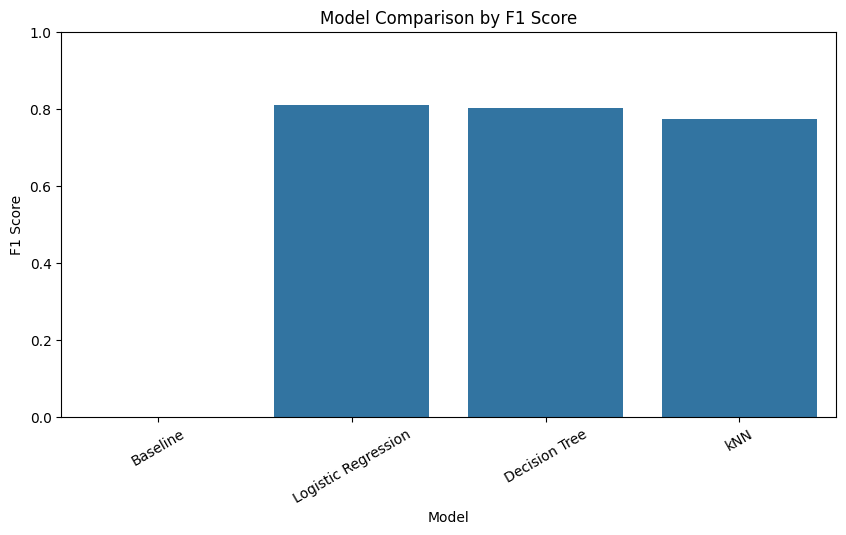

In [21]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results, x="model", y="f1")
plt.title("Model Comparison by F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.show()

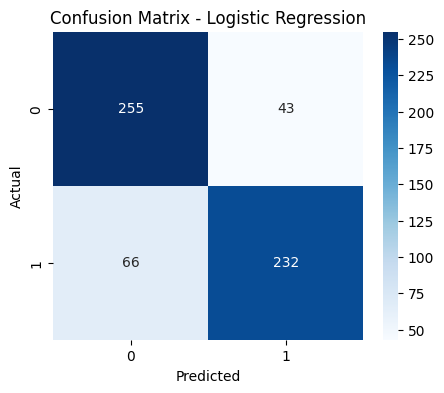

In [22]:
cm = confusion_matrix(y_test, log_reg_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix shows how many wins and losses were correctly or incorrectly classified. False positives correspond to matches predicted as wins but actually lost, while false negatives correspond to matches predicted as losses but actually won.

In [23]:
depth_results = []

for depth in range(1, 11):
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=depth,
            min_samples_leaf=10,
            random_state=42
        ))
    ])
    
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="f1")
    
    depth_results.append({
        "max_depth": depth,
        "mean_cv_f1": scores.mean(),
        "std_cv_f1": scores.std()
    })

depth_results = pd.DataFrame(depth_results)
depth_results

,max_depth,mean_cv_f1,std_cv_f1
0,1,0.794268,0.020336
1,2,0.794268,0.020336
2,3,0.788385,0.018161
3,4,0.796885,0.011073
4,5,0.795651,0.018079
5,6,0.794168,0.019183
6,7,0.796427,0.020041
7,8,0.784107,0.017245
8,9,0.778723,0.016315
9,10,0.776794,0.024265


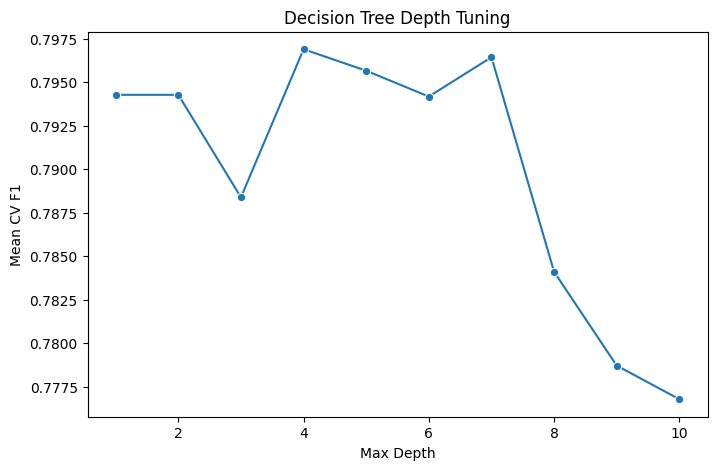

In [24]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=depth_results, x="max_depth", y="mean_cv_f1", marker="o")
plt.title("Decision Tree Depth Tuning")
plt.xlabel("Max Depth")
plt.ylabel("Mean CV F1")
plt.show()

Tree depth controls model complexity. A very shallow tree may underfit, while a very deep tree may overfit. Cross-validation was used to choose a reasonable depth.

In [25]:
k_results = []

for k in range(1, 22, 2):
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier(n_neighbors=k))
    ])
    
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="f1")
    
    k_results.append({
        "k": k,
        "mean_cv_f1": scores.mean(),
        "std_cv_f1": scores.std()
    })

k_results = pd.DataFrame(k_results)
k_results

,k,mean_cv_f1,std_cv_f1
0,1,0.698304,0.009194
1,3,0.741842,0.014258
2,5,0.759014,0.013512
3,7,0.766233,0.016854
4,9,0.770700,0.020968
5,11,0.771419,0.028934
6,13,0.785723,0.026881
7,15,0.786120,0.025088
8,17,0.789289,0.025078
9,19,0.794350,0.022355


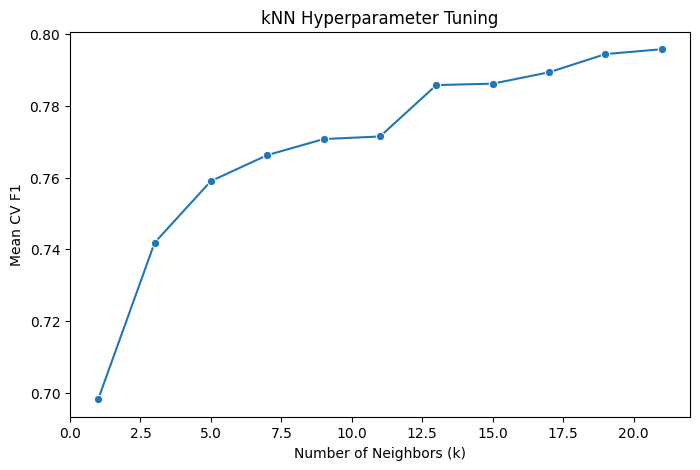

In [26]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=k_results, x="k", y="mean_cv_f1", marker="o")
plt.title("kNN Hyperparameter Tuning")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean CV F1")
plt.show()

The value of k is a hyperparameter in kNN. Small k values may be sensitive to noise, while large k values may oversmooth the decision boundary.

In [27]:
best_tree = tree_model.named_steps["classifier"]
preprocessor_fitted = tree_model.named_steps["preprocessor"]

encoded_cat_features = preprocessor_fitted.named_transformers_["cat"]["onehot"].get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numeric_features, encoded_cat_features])

feature_importance = pd.DataFrame({
    "feature": all_feature_names,
    "importance": best_tree.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(15)

,feature,importance
0,kda,0.950274
1,damage_per_min,0.018330
9,role_TOP,0.016493
7,role_JUNGLE,0.007041
2,vision_per_min,0.006359
4,deaths,0.001503
5,assists,0.000000
3,kills,0.000000
6,role_BOTTOM,0.000000
8,role_MIDDLE,0.000000


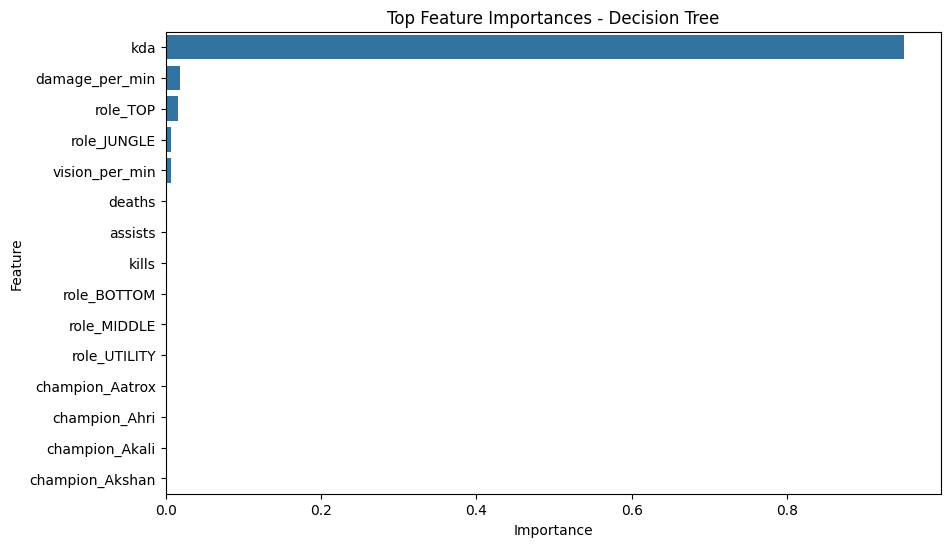

In [28]:
top_importance = feature_importance.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_importance, x="importance", y="feature")
plt.title("Top Feature Importances - Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Feature importance helps identify which variables the decision tree uses most for predicting match outcome.

In [29]:
log_reg_classifier = log_reg_model.named_steps["classifier"]
preprocessor_fitted = log_reg_model.named_steps["preprocessor"]

encoded_cat_features = preprocessor_fitted.named_transformers_["cat"]["onehot"].get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numeric_features, encoded_cat_features])

coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": log_reg_classifier.coef_[0]
}).sort_values("coefficient", ascending=False)

coef_df.head(15), coef_df.tail(15)

(               feature  coefficient
 68    champion_Karthus     1.655401
 0                  kda     1.429592
 5              assists     1.267213
 41      champion_Elise     1.202296
 123     champion_Senna     0.936951
 3                kills     0.892892
 109      champion_Pyke     0.863742
 16    champion_Ambessa     0.825927
 89   champion_MasterYi     0.798190
 104      champion_Olaf     0.793770
 111     champion_Quinn     0.748064
 142     champion_Teemo     0.718653
 77     champion_KogMaw     0.711638
 35      champion_Corki     0.701357
 71      champion_Kayle     0.693958,
                feature  coefficient
 84       champion_Lulu    -0.727326
 58      champion_Janna    -0.753085
 74     champion_Khazix    -0.808779
 96       champion_Nami    -0.809230
 170       champion_Zed    -0.846332
 14     champion_Akshan    -0.867949
 4               deaths    -0.873721
 90        champion_Mel    -0.909113
 112     champion_Rakan    -0.927183
 134    champion_Soraka    -0.977495


Positive coefficients increase the predicted probability of winning, while negative coefficients decrease it.

In [30]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba))
print(confusion_matrix(y_test, rf_pred))

Random Forest
Accuracy: 0.8171140939597316
Precision: 0.8620689655172413
Recall: 0.7550335570469798
F1: 0.8050089445438283
ROC-AUC: 0.8920881942254852
[[262  36]
 [ 73 225]]


## Main Findings
1. For machine learning, the target variable was match outcome (win/loss).
2. Logistic Regression, Decision Tree, and kNN models were trained and compared.
3. The best model was selected based on test-set F1 score and ROC-AUC.

## Most Important Features for Prediction

To understand which variables were most useful for predicting match outcome, I examined feature importance from the Decision Tree model and coefficients from the Logistic Regression model.

The Decision Tree feature importance values show which variables were most frequently and effectively used to split the data. The most important features were:

1. `kda`
2. `damage_per_min`
3. `role_TOP`
4. `role_JUNGLE`
5. `vision_per_min`

The Logistic Regression coefficients show the direction of the relationship between each feature and the predicted probability of winning. Positive coefficients increase the predicted probability of a win, while negative coefficients decrease it.

The strongest positive predictors were:
1. `champion_Karthus`     
2. `kda`  
3. `assists`

The strongest negative predictors were:

1. `champion_Galio`
2. `champion_Jhin`   
3. `champion_Taric`

## Overall Most Important Features for Prediction

Based on the Decision Tree feature importance and Logistic Regression coefficients, the most important features for predicting match outcome appear to be `kda`, `damage_per_min`, `vision_per_min`, `role`, and some champion-specific variables.

The most consistent feature across both models is `kda`. It appears as the most important Decision Tree feature and also has a strong positive coefficient in Logistic Regression. This suggests that players with better kill/death/assist performance are more likely to be associated with winning matches.

The Decision Tree model also identified `damage_per_min` and `vision_per_min` as important predictors. These are useful because they normalize performance by match duration and allow fairer comparisons across games of different lengths.

Role-related variables such as `role_TOP` and `role_JUNGLE` were also important in the Decision Tree model, suggesting that the relationship between role and match outcome may differ across positions.

In Logistic Regression, some champion-specific variables such as `champion_Karthus`, `champion_Galio`, `champion_Jhin`, and `champion_Taric` had strong coefficients. However, champion-specific coefficients should be interpreted carefully because they may be affected by small sample sizes or the specific champions that appeared in the collected dataset.

Overall, the strongest and most reliable predictors are `kda`, `damage_per_min`, `vision_per_min`, and `role`. Champion variables may also contribute to prediction, but they should be interpreted with caution.